<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Introducción a datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2025/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo:

Karen Cardona Gutierrez - karen.cardonag@udea.edu.co

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

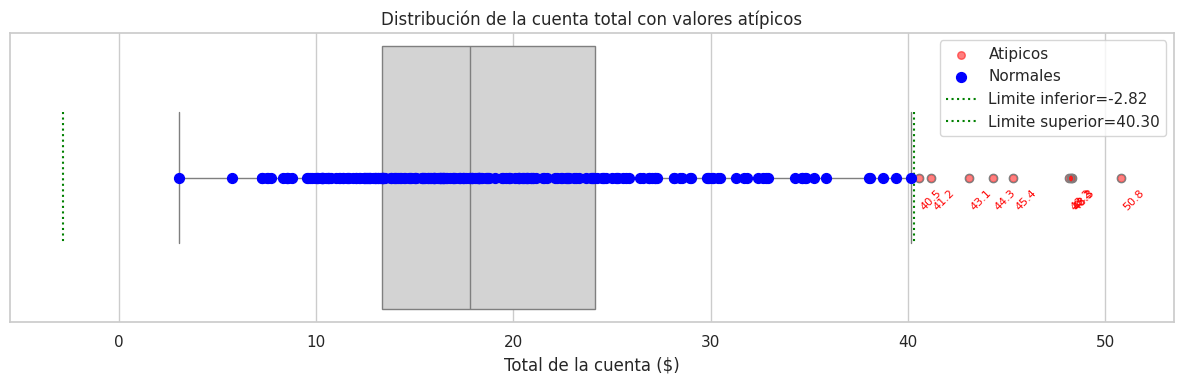

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

data_outliers= total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_normales = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(12,4))
plt.title("Distribución de la cuenta total con valores atípicos")
sns.boxplot(x=total_bill, color="lightgray",)
plt.scatter(data_outliers, [0]*len(data_outliers), color="red", s=30, alpha=0.5,label= "Atipicos")
plt.scatter(data_normales, [0]*len(data_normales), color="blue", s=50, zorder=5,label= "Normales")
plt.vlines(lim_inf, ymin=-0.2, ymax=0.2, color="green", linestyle=":",label= f"Limite inferior={lim_inf:.2f}")
plt.vlines(lim_sup, ymin=-0.2, ymax=0.2, color="green", linestyle=":",label= f"Limite superior={lim_sup:.2f}")
for val in data_outliers:
    plt.text(val, 0.1, f"{val:.1f}", rotation=45, fontsize=8, color="red")
plt.legend()
plt.xlabel("Total de la cuenta ($)")
plt.tight_layout()
plt.show()

La mayoría de los datos se concentran entre 13 y 24 dólares, lo que refleja la tendencia central del gasto en cuentas. Se identifican valores atípicos hacia la derecha, que superan el límite superior (40 dólares); estos corresponden a consumos poco frecuentes pero posibles en el contexto del restaurante. No se observan atípicos hacia la izquierda porque el límite inferior calculado es negativo (-2.82), un valor que carece de sentido en este tipo de variable, ya que una cuenta no puede ser negativa.


# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

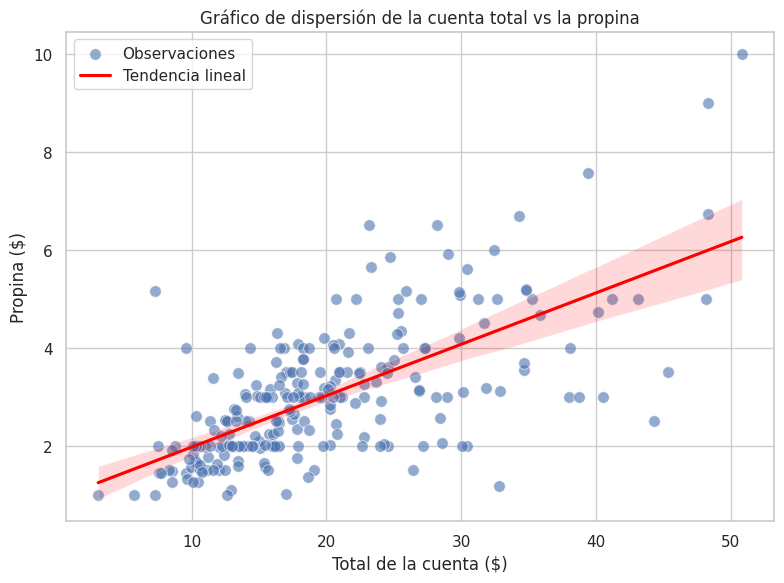

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tips = sns.load_dataset("tips")

x = tips["total_bill"].values
y = tips["tip"].values


plt.figure(figsize=(8,6))
plt.title("Gráfico de dispersión de la cuenta total vs la propina")
plt.xlabel("Total de la cuenta ($)")
plt.ylabel("Propina ($)")
sns.scatterplot(x=x, y=y, s=70,alpha=0.6, label="Observaciones")
sns.regplot(x=x, y=y, data=tips, scatter=False, color="red", label="Tendencia lineal")
plt.tight_layout()
plt.legend()
plt.show()


De acuerdo con la línea de tendencia, existe una relación positiva clara entre el total de la cuenta y la propina: a mayor consumo, mayor propina. Sin embargo, la dispersión aumenta con cuentas más altas: no todas las personas dan propina de manera consistente frente a consumos elevados. Se observan algunos valores atípico, como consumos elevados con propinas bajas y viceversa. Esto indica que la relación es moderada, pero no completamente consistente, ya que influyen otros factores individuales.


# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

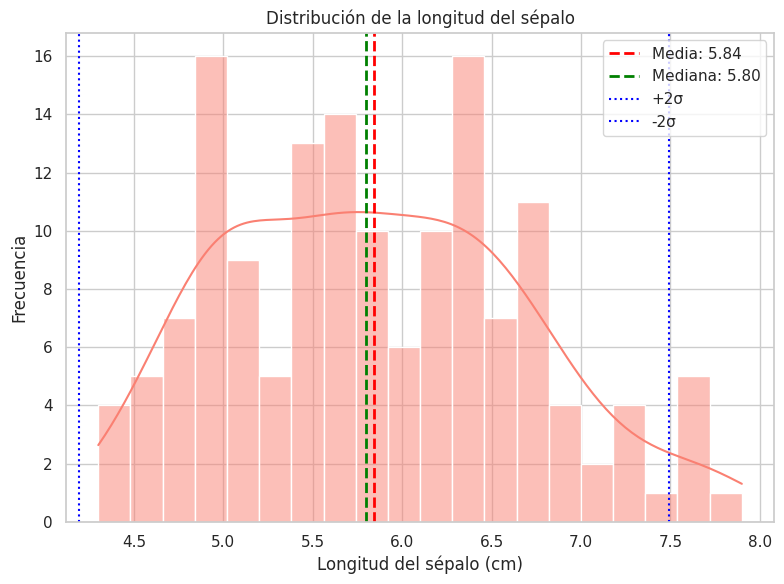

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True, color="salmon")
plt.title("Distribución de la longitud del sépalo")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Frecuencia")
plt.axvline(np.mean(x), color="red", linestyle="--", linewidth=2, label=f"Media: {np.mean(x):.2f}")
plt.axvline(np.median(x), color="green", linestyle="--", linewidth=2, label=f"Mediana: {np.median(x):.2f}")
plt.axvline(np.mean(x) + 2*np.std(x), color="blue", linestyle=":", label="+2σ")
plt.axvline(np.mean(x) - 2*np.std(x), color="blue", linestyle=":", label="-2σ")
plt.tight_layout()
plt.legend()
plt.show()


La distribución de la longitud del sépalo se concentra principalmente entre 5 y 6.5 cm, con pocos valores extremos por encima de 7.5 cm que pueden considerarse atípicos, se aprecia que no existen valores atípicos hacia la izquierda, ya que ninguna observación se ubica por debajo del límite inferior. En general, la presencia de outliers es limitada y la distribución conserva una forma relativamente estable.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

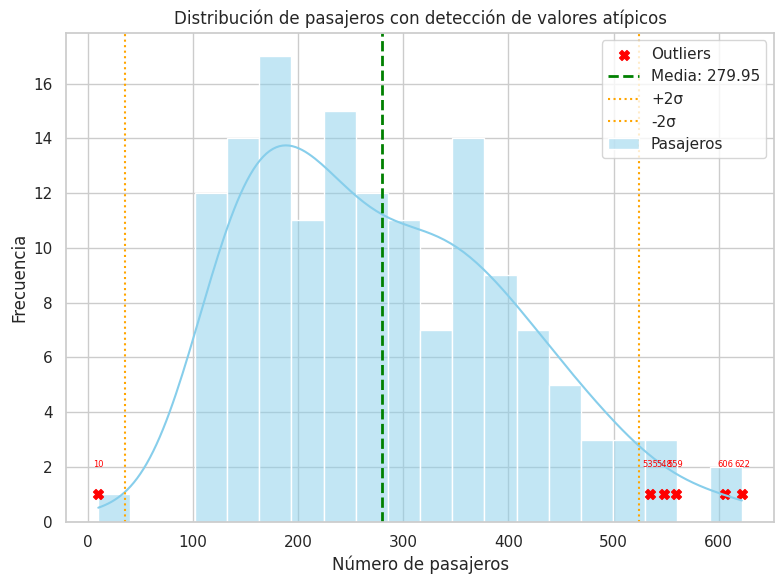

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

x = np.append(x, [10, 500])

z_scores = zscore(x)
outliers = np.abs(z_scores) > 2

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True, color="skyblue", label="Pasajeros")
plt.scatter(x[outliers],  np.full_like(x[outliers], 1), color="red", s=50, marker="X",label="Outliers")
for val in x[outliers]:
    plt.text(val, 2, str(int(val)), color="red", ha="center", fontsize= 6)

plt.axvline(np.mean(x), color="green", linestyle="--", linewidth=2, label=f"Media: {np.mean(x):.2f}")
plt.axvline(np.mean(x) + 2*np.std(x), color="orange", linestyle=":", label="+2σ")
plt.axvline(np.mean(x) - 2*np.std(x), color="orange", linestyle=":", label="-2σ")

plt.title("Distribución de pasajeros con detección de valores atípicos")
plt.xlabel("Número de pasajeros")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()


La mayoría de los valores se concentran cerca de la media (280 pasajeros), dentro del rango esperado de variabilidad. Sin embargo, aparecen outliers a la izquierda (valores muy bajos de pasajeros, cercanos a 10) y outliers a la derecha (valores superiores a 500), que se alejan más de 2 desviaciones estándar. Estos puntos extremos indican registros poco comunes que no siguen la tendencia central de la distribución.

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

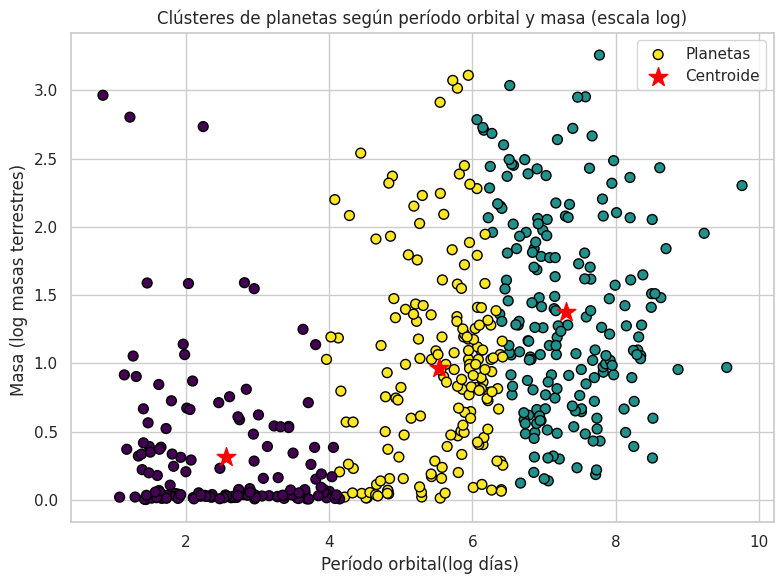

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,6))
sns.set(style="whitegrid")
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50, edgecolor= "black", label="Planetas")
plt.scatter(centroids[:,0], centroids[:,1], c="red", s=200, marker="*", label="Centroide")

plt.title("Clústeres de planetas según período orbital y masa (escala log)")
plt.xlabel("Período orbital(log días) ")
plt.ylabel("Masa (log masas terrestres) ")

plt.legend()
plt.tight_layout()
plt.show()


En la gráfica se observa que, aunque los planetas tienden a agruparse en tres clústeres bien definidos, existen puntos que se alejan notablemente de sus respectivos centroides. Estos planetas corresponden a valores atípicos, ya sea porque presentan un período orbital muy largo respecto a su masa, o porque poseen masas relativamente altas en clústeres donde predominan masas bajas. Tales casos indican configuraciones poco frecuentes que no siguen el patrón general de su grupo, pero que aportan información relevante sobre la diversidad de los sistemas planetarios.